# Chandra/HETG observation of Vela X-1 (2001) — detector-space analysis

BLiSS applied to the Chandra HETG spectrum of Vela X-1 (ObsID 1927) loaded directly
from the OGIP files. HEG and MEG are analysed separately: they have different
resolutions and effective-area curves, so combining them would average two responses.

The ±1 orders of each arm were combined with CIAO:

    combine_spectra src_spectra="heg_-1.pha.gz,heg_1.pha.gz" outroot=heg \
        src_arfs="heg_-1.arf.gz,heg_1.arf.gz" src_rmfs="heg_-1.rmf.gz,heg_1.rmf.gz" \
        method=sum clobber=yes

In this mode BLiSS rebins the spectrum conserving counts, works in counts s⁻¹ keV⁻¹,
and calibrates every candidate against line-free spectra drawn as Poisson counts at
channel resolution and pushed through the same rebinning and baseline estimation as
the data. A companion notebook (`vela_x1_2001_dat.ipynb`) runs the same object from a
plain text spectrum, for comparison.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bliss import *
from bliss.line_search.blind_line_search import prepare_spectrum

config = BlindLineSearchConfig(baseline_window=0.2)
pipeline = BlindLineSearchPipeline(config=config)

## 1. Input files, output folder and energy range

In [2]:
chandra_path = Path("obs_1927_tgid_4659")

heg_pha = chandra_path / "heg.pha"
heg_rmf = chandra_path / "heg.rmf"
heg_arf = chandra_path / "heg.arf"

meg_pha = chandra_path / "meg.pha"
meg_rmf = chandra_path / "meg.rmf"
meg_arf = chandra_path / "meg.arf"

output_dir = Path("results_vela_x1_2001_pha")
output_dir.mkdir(exist_ok=True)

# Energy range used throughout
en1, en2 = 0.5, 8

## 2. Load and inspect the HEG spectrum

`prepare_spectrum` is the function the pipeline uses internally. With
`rebin_method="none"` it returns the spectrum at native channel resolution, already
converted to counts s⁻¹ keV⁻¹. The `.native` attribute keeps the channel-level counts
and exposure used later for the Poisson null.

channels      : 8192
exposure [s]  : 58862.078930584
median ΔE [eV]: 0.2453923225402832


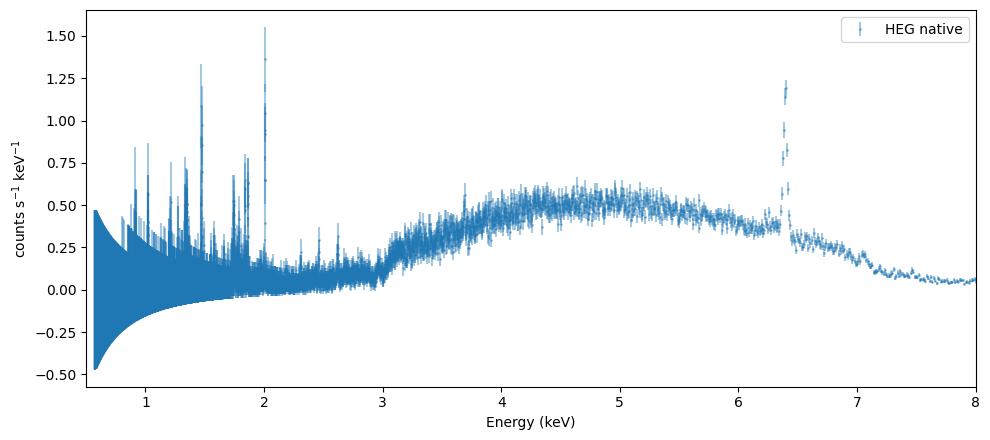

In [3]:
heg_native = prepare_spectrum(heg_pha, heg_rmf, heg_arf, rebin_method="none")

print("channels      :", len(heg_native.energy))
print("exposure [s]  :", heg_native.native.exposure)
print("median ΔE [eV]:", 1e3 * np.median(heg_native.bin_width))

plt.figure(figsize=(10, 4.5))
plt.errorbar(heg_native.energy, heg_native.values, yerr=heg_native.uncertainties,
             fmt=".", ms=2, alpha=0.4, label="HEG native")
plt.xlim(en1, en2)
plt.xlabel("Energy (keV)")
plt.ylabel("counts s$^{-1}$ keV$^{-1}$")
plt.legend()
plt.tight_layout()
plt.show()

## 3. Rebin the spectrum conserving counts

Three schemes are available (`rebin_method`): `"bins"` groups a fixed number of
channels, `"resolution"` uses fixed-width intervals in keV, and `"snr"` accumulates
channels until a signal-to-noise threshold. All of them **sum** counts, so the result
stays Poisson. We use a fixed resolution of 3 eV. The same scheme will be applied to
every synthetic null realization inside the pipeline.

In [4]:
rebin_method = "resolution"
rebin_scale = 0.001   # keV

heg = prepare_spectrum(heg_pha, heg_rmf, heg_arf,
                                rebin_method=rebin_method, rebin_scale=rebin_scale)

counts_per_bin = heg.values * heg.native.exposure * heg.bin_width
print("bins after rebinning:", len(heg.energy))
print("median counts/bin   :", np.median(counts_per_bin))

bins after rebinning: 3477
median counts/bin   : 5.0


### 3.1 Empirical baseline

The baseline is a running median in physical energy units (`baseline_window`, default
0.4 keV). It is the line-free model from which the Poisson null spectra are drawn.

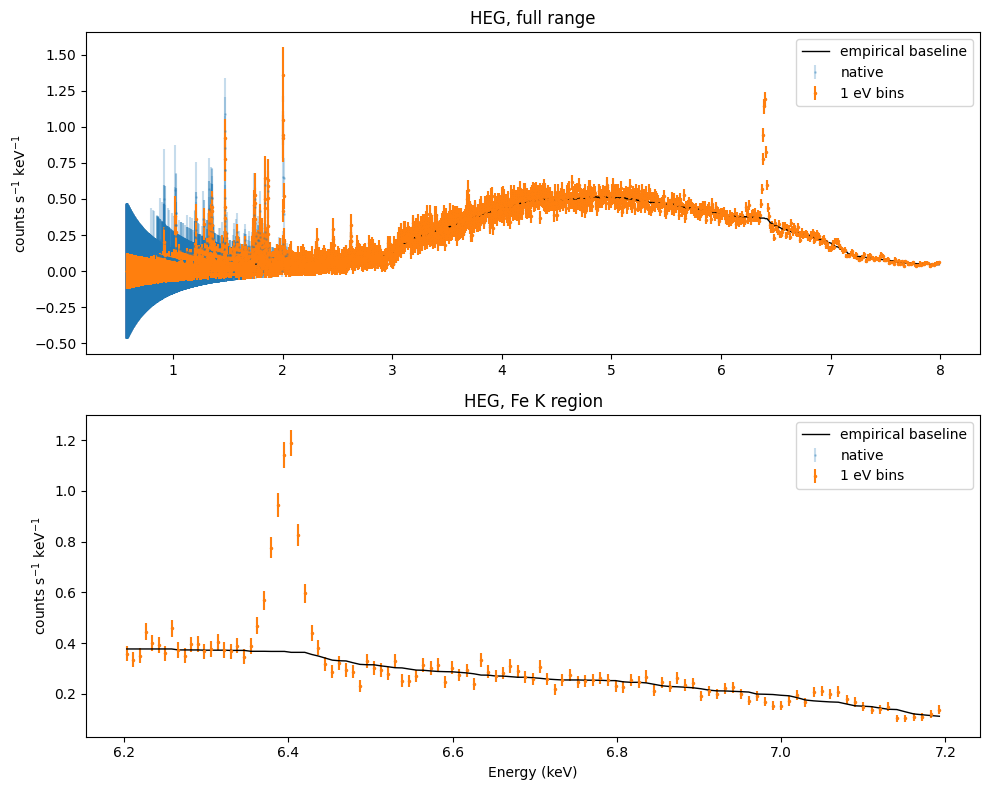

In [5]:
baseline_heg = base_calculator(heg.energy, heg.values)

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for ax, xlim, title in zip(axes, [(en1, en2), (6.2, 7.2)], ["full range", "Fe K region"]):
    m0 = (heg_native.energy >= xlim[0]) & (heg_native.energy <= xlim[1])
    m1 = (heg.energy >= xlim[0]) & (heg.energy <= xlim[1])
    ax.errorbar(heg_native.energy[m0], heg_native.values[m0], yerr=heg_native.uncertainties[m0],
                fmt=".", ms=2, alpha=0.25, label="native")
    ax.errorbar(heg.energy[m1], heg.values[m1], yerr=heg.uncertainties[m1],
                fmt=".", ms=3, label=f"{1e3*rebin_scale:.0f} eV bins")
    ax.plot(heg.energy[m1], baseline_heg[m1], "k-", lw=1, label="empirical baseline")
    ax.set_title(f"HEG, {title}")
    ax.set_ylabel("counts s$^{-1}$ keV$^{-1}$")
    ax.legend()
axes[1].set_xlabel("Energy (keV)")
plt.tight_layout()
plt.show()

## 4. Candidate search (HEG)

`find_candidate_lines` takes the PHA/RMF/ARF paths and the rebinning scheme, so that
the null realizations follow exactly the same chain as the data.
`num_synthetic_simulations` sets the number of null spectra.

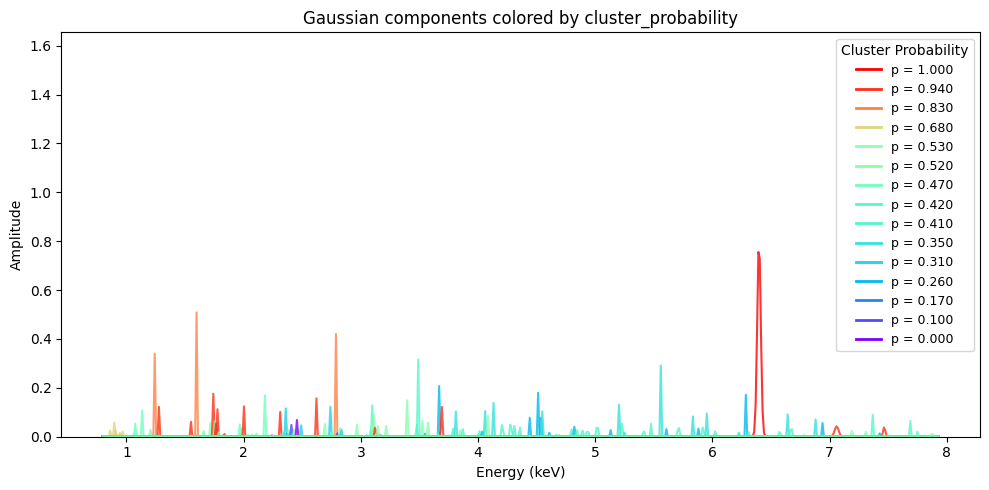

,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,0.852711,2.139029e-04,0.000989,0.000219,0.021965,0.004042,1.000000,0.085085,0.019312,0.000000,0.258150,5.434385e+00,0.000054,0.000016,3.476853e+00,NaN,0.68
1,0.858198,6.901092e-07,0.000251,0.000008,0.112398,0.014064,1.000000,0.084050,0.019087,0.000000,1.337284,7.991667e+00,0.000071,0.000009,7.714755e+00,NaN,0.68
2,0.861178,6.948132e-07,0.000253,0.000009,0.111611,0.013966,1.000000,0.083468,0.018955,0.000000,1.337177,7.991811e+00,0.000071,0.000009,7.714866e+00,NaN,0.68
3,0.878402,5.340867e-04,0.000513,0.000608,0.042676,0.044132,1.000000,0.083763,0.036374,0.000000,0.509489,9.670142e-01,0.000055,0.000086,6.356638e-01,NaN,0.68
4,0.896164,1.098161e-08,0.000260,0.000009,0.100295,0.012527,1.000000,0.080230,0.017505,0.000000,1.250086,8.006043e+00,0.000065,0.000008,7.696932e+00,NaN,0.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349,7.515527,3.237420e+03,0.002589,3162.437618,0.045235,252575.995012,0.067366,0.012068,0.086415,0.075507,3.748282,1.790962e-07,0.000294,1678.073737,1.749594e-07,3.888320,0.35
350,7.588443,1.983806e-04,0.000433,0.000226,0.032044,0.000002,0.111664,0.011239,0.083391,0.066638,2.851026,1.359910e+04,0.000035,0.000018,1.918780e+00,0.522514,0.31
351,7.688370,4.521301e+02,0.002919,1135.548933,0.064351,103377.390074,0.094060,0.010211,0.068510,0.056730,6.301888,6.224866e-07,0.000471,778.283915,6.050015e-07,8.300031,0.42
352,7.750372,8.493695e+02,0.002853,896.671744,0.030715,41308.769380,0.070119,0.010011,0.060240,0.052345,3.068321,7.435573e-07,0.000220,303.361233,7.240471e-07,4.196134,0.42


In [6]:
N_SIM = 100
SEED = 1

heg_candidates = find_candidate_lines(
    pha=heg_pha, rmf=heg_rmf, arf=heg_arf,
    rebin_method=rebin_method, rebin_scale=rebin_scale,
    en1=en1, en2=en2,
    num_synthetic_simulations=N_SIM, synthetic_seed=SEED,
    output_dir=output_dir)

plot_line_prob(heg_candidates)
heg_candidates

## 5. Filter candidates and perform a global fit (HEG)

Candidates are kept if they pass a cluster-probability threshold, at least one
significance criterion, and a minimum relative contribution. The global
multi-Gaussian fit is done on the same rebinned spectrum used for the search.

In [16]:
P_MIN = 0.      # minimum cluster probability (0-1)
REL_POWER_MIN = 0  # minimum relative contribution of the line (0-1)
SNR_PEAK_MIN = 0    # a line is kept if at least one S/N criterion is met
SNR_AREA_MIN = 0
SNR_AMPLITUDE_MIN = 0

lines_pd = heg_candidates
clean_mask = (
    (lines_pd["cluster_probability"] >= P_MIN)
    & (
        (lines_pd["snr_peak"] >= SNR_PEAK_MIN)
        | (lines_pd["snr_area"] >= SNR_AREA_MIN)
        | (lines_pd["snr_amplitude"] >= SNR_AMPLITUDE_MIN)
    )
    & (lines_pd["relative_power"] >= REL_POWER_MIN)
)
heg_lines = lines_pd.loc[clean_mask].reset_index(drop=True)
print(f"{len(heg_lines)} of {len(lines_pd)} candidates kept")

350 of 354 candidates kept


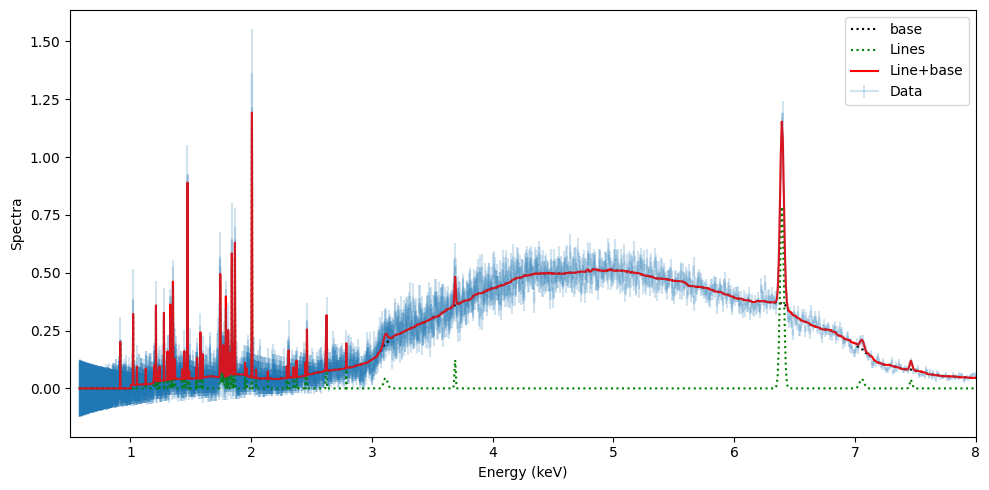

In [8]:
heg_lines_global = fit_global(
    heg_lines,
    heg,
    energy_min=en1, energy_max=en2,
    output_dir=output_dir,
)

## 6. Identify emission lines within a Doppler velocity window (HEG)

Fitted centroids are compared with a reference list of transitions. A line is
tentatively identified when its energy is consistent with a transition within the
chosen velocity window.

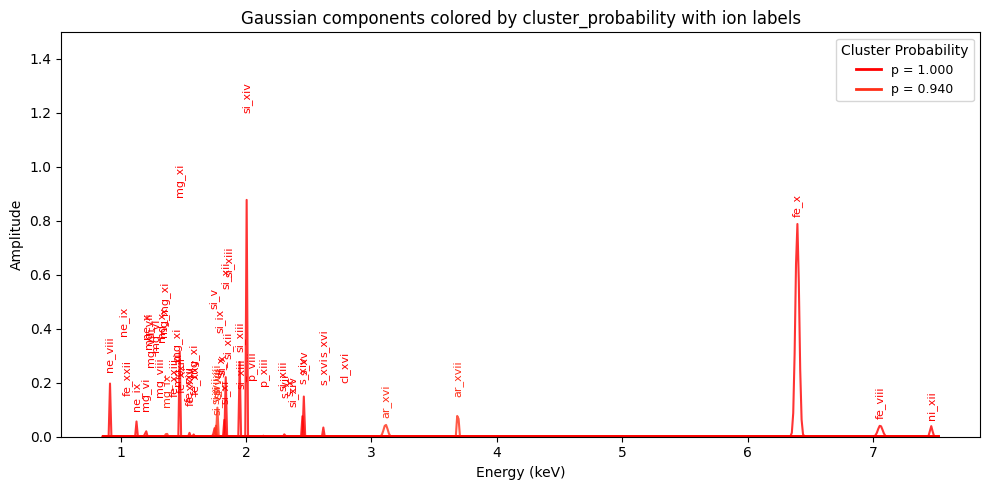

,ion,doppler_kms,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,ne_viii,-373.386686,0.915427,0.000396,0.000671,0.000380,0.217175,0.121566,1.000000,0.088632,0.200970,0.000000,2.450300,1.786473,0.000365,0.000291,1.256276,NaN,1.00
1,ne_ix,57.496730,1.022240,0.000290,0.000830,0.000253,0.347759,0.115073,0.923224,0.085094,0.383371,0.015304,4.086754,3.022082,0.000723,0.000325,2.223147,46.570742,1.00
2,fe_xxii,-294.199123,1.054329,0.002920,0.000415,0.006218,0.126735,2.704121,0.704922,0.075272,0.094668,0.016385,1.683706,0.046867,0.000132,0.003437,0.038353,7.328798,1.00
3,ne_ix,56.417241,1.127341,0.001340,0.001377,0.001278,0.070424,0.061638,0.652986,0.074657,0.082827,0.017388,0.943296,1.142550,0.000243,0.000310,0.783853,13.568959,1.00
4,mg_vi,-551.728212,1.199302,0.001925,0.003120,0.001852,0.071569,0.040669,0.608370,0.074086,0.117078,0.028508,0.966025,1.759787,0.000560,0.000460,1.216776,18.656442,1.00
5,ne_x,123.046088,1.211517,0.000269,0.000663,0.000205,0.336947,0.109654,0.841339,0.080012,0.358686,0.030907,4.211215,3.072826,0.000560,0.000252,2.225275,18.539033,1.00
6,mg_vii,46.331327,1.225209,0.290740,0.000264,4.922245,0.301631,22527.170662,0.402707,0.069237,0.074898,0.031893,4.356498,0.000013,0.000200,15.389392,0.000013,1.223444,1.00
7,mg_viii,-286.324544,1.241240,2.679007,0.000287,4.894003,0.235540,14113.042086,0.495249,0.067872,0.095628,0.032281,3.470353,0.000017,0.000169,10.555834,0.000016,2.440362,1.00
8,mg_vi,66.476100,1.277694,0.000345,0.000476,0.000171,0.291721,0.109089,0.806244,0.075321,0.326865,0.035063,3.873023,2.674150,0.000348,0.000181,1.927491,8.216186,1.00
9,mg_viii,302.868905,1.307833,0.000670,0.001016,0.000622,0.123703,0.075398,0.593897,0.072412,0.147818,0.037662,1.708315,1.640667,0.000315,0.000272,1.157775,7.968256,1.00


In [9]:
max_doppler_velocity = 600  # km/s

heg_lines_ion = add_most_probable_ion(heg_lines_global, max_doppler_velocity)
plot_line_prob(heg_lines_ion)
heg_lines_ion

In [10]:
# All transitions compatible with each line within the velocity window
compatible_heg = get_all_compatible_lines(heg_lines_global, max_doppler_velocity)
compatible_heg[0].head()

,ion,energy_keV,doppler_kms
0,ne_viii,0.916568,-373.386686
1,ne_viii,0.916772,-439.784792
2,ne_viii,0.914540,290.659389
3,ne_viii,0.914675,246.385503
4,ne_ix,0.915013,135.716950


## 7. MEG

The MEG arm has more effective area below ~2 keV but half the resolution of HEG and
almost no counts above ~5 keV. The procedure is identical.

channels: 8192  bins: 2654  exposure [s]: 58862.078930584


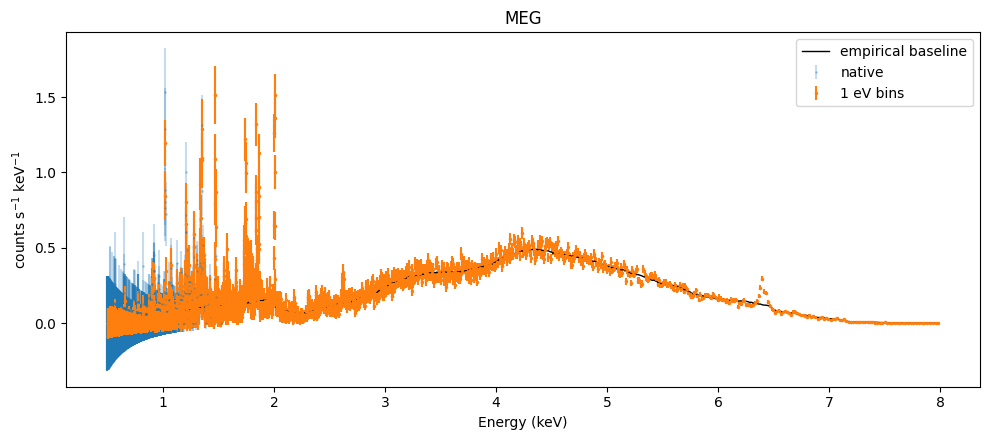

In [11]:
meg_native = prepare_spectrum(meg_pha, meg_rmf, meg_arf, rebin_method="none")
meg = prepare_spectrum(meg_pha, meg_rmf, meg_arf,
                                rebin_method=rebin_method, rebin_scale=rebin_scale)
baseline_meg = base_calculator(meg.energy, meg.values)

print("channels:", len(meg_native.energy), " bins:", len(meg.energy),
      " exposure [s]:", meg.native.exposure)

m0 = (meg_native.energy >= en1) & (meg_native.energy <= en2)
m1 = (meg.energy >= en1) & (meg.energy <= en2)
plt.figure(figsize=(10, 4.5))
plt.errorbar(meg_native.energy[m0], meg_native.values[m0], yerr=meg_native.uncertainties[m0],
             fmt=".", ms=2, alpha=0.25, label="native")
plt.errorbar(meg.energy[m1], meg.values[m1], yerr=meg.uncertainties[m1],
             fmt=".", ms=3, label=f"{1e3*rebin_scale:.0f} eV bins")
plt.plot(meg.energy[m1], baseline_meg[m1], "k-", lw=1, label="empirical baseline")
plt.xlabel("Energy (keV)")
plt.ylabel("counts s$^{-1}$ keV$^{-1}$")
plt.title("MEG")
plt.legend()
plt.tight_layout()
plt.show()

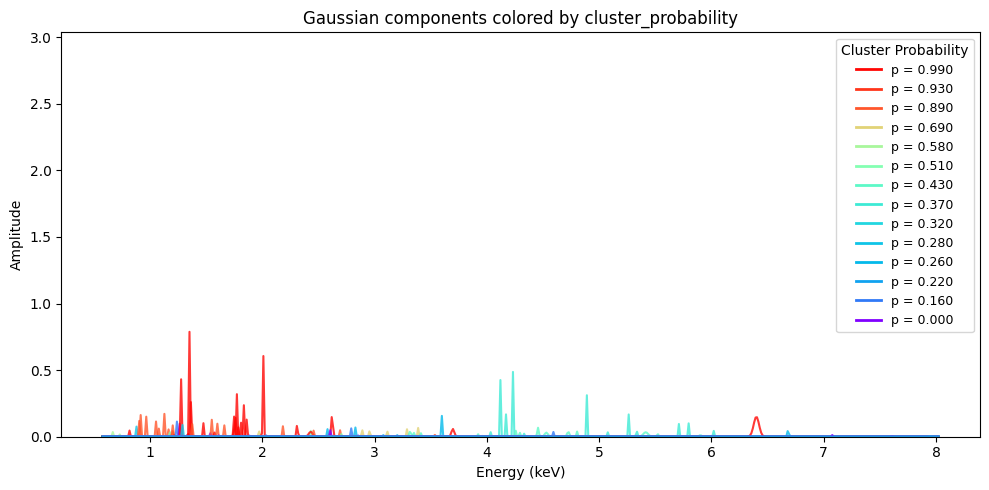

,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,0.653845,2.548102e-06,0.000531,0.000002,0.149501,0.000337,1.000000,0.083791,0.147775,0.000000,1.784209,443.821486,1.990061e-04,7.445596e-07,2.672802e+02,NaN,0.58
1,0.668526,8.351061e-07,0.000260,0.000009,0.106038,0.013157,1.000000,0.075382,0.018824,0.000000,1.406673,8.059369,6.909318e-05,8.891986e-06,7.770275e+00,NaN,0.58
2,0.698461,2.571677e-06,0.000243,0.000007,0.191150,0.023794,1.000000,0.074901,0.034584,0.000000,2.552036,8.033479,1.166048e-04,1.494949e-05,7.799918e+00,NaN,0.58
3,0.729962,3.778419e-04,0.001772,0.000401,0.020242,0.003657,1.000000,0.072033,0.019765,0.000000,0.281014,5.534492,8.989721e-05,2.602060e-05,3.454847e+00,NaN,0.58
4,0.741295,5.108846e-05,0.000729,0.000056,0.085812,0.005515,1.000000,0.073655,0.076727,0.000000,1.165057,15.559675,1.568559e-04,1.578829e-05,9.934952e+00,NaN,0.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,6.683695,5.004086e+01,0.004435,985.149400,0.081304,74508.691806,0.075430,0.008755,0.077535,0.066658,9.286568,0.000001,9.037898e-04,8.522357e+02,1.060493e-06,13.558518,0.26
213,6.790912,0.000000e+00,0.004829,0.000000,0.000003,0.000000,-0.049289,0.006832,0.048509,0.053538,0.000504,NaN,4.170885e-08,0.000000e+00,NaN,0.000779,0.22
214,7.077645,4.185874e+03,0.002813,4102.643986,0.015777,481.713923,0.153483,0.005761,0.034508,0.025325,2.738767,0.000033,1.112472e-04,1.622864e+02,6.854994e-07,4.392837,0.00
215,7.609560,3.316084e-02,0.010044,0.052724,0.002108,0.013892,0.202952,0.002316,0.004355,0.002886,0.910300,0.151773,5.308689e-05,4.472058e-04,1.187080e-01,18.396195,0.00


In [12]:
meg_candidates = find_candidate_lines(
    pha=meg_pha, rmf=meg_rmf, arf=meg_arf,
    rebin_method=rebin_method, rebin_scale=rebin_scale,
    en1=en1, en2=en2,
    num_synthetic_simulations=N_SIM, synthetic_seed=SEED,
    output_dir=output_dir,
)
plot_line_prob(meg_candidates)
meg_candidates

In [13]:
lines_pd = meg_candidates
clean_mask = (
    (lines_pd["cluster_probability"] >= P_MIN)
    & (
        (lines_pd["snr_peak"] >= SNR_PEAK_MIN)
        | (lines_pd["snr_area"] >= SNR_AREA_MIN)
        | (lines_pd["snr_amplitude"] >= SNR_AMPLITUDE_MIN)
    )
    & (lines_pd["relative_power"] >= REL_POWER_MIN)
)
meg_lines = lines_pd.loc[clean_mask].reset_index(drop=True)
print(f"{len(meg_lines)} of {len(lines_pd)} candidates kept")

52 of 217 candidates kept


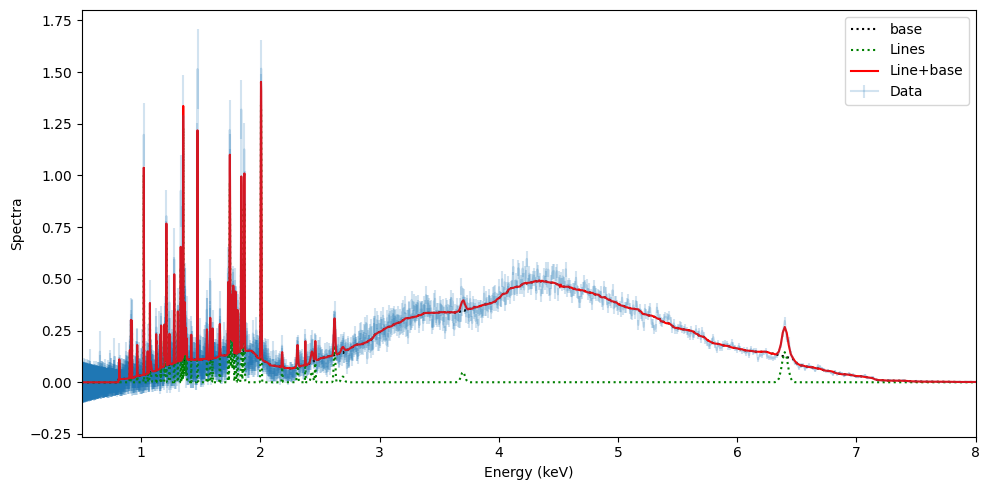

In [14]:
meg_lines_global = fit_global(
    meg_lines,
    meg,
    energy_min=en1, energy_max=en2,
    output_dir=output_dir,
)

In [15]:
meg_lines_global

,center,ecenter,sigma,esigma,amplitude,eamplitude,relative_power,noise_on_block,value_on_line,base_on_line,snr_peak,snr_amplitude,area,earea,snr_area,ew,cluster_probability
0,0.817333,0.014824,0.000357,0.015690,0.137622,9.235189e+00,0.767363,0.067731,0.110438,0.014537,2.031885,1.490194e-02,0.000123,0.009872,1.246250e-02,8.641949,1.00
1,0.905499,0.000855,0.002184,0.000809,0.138082,5.150382e-02,0.832805,0.071828,0.205362,0.018734,1.922404,2.681010e+00,0.000756,0.000397,1.902584e+00,38.074209,1.00
2,0.915225,0.000287,0.000713,0.000309,0.324964,1.199186e-01,0.879695,0.082322,0.302005,0.019329,3.947478,2.709875e+00,0.000580,0.000331,1.755483e+00,29.504869,1.00
3,0.922502,0.000276,0.000908,0.000253,0.326523,9.922090e-02,0.875932,0.082322,0.297349,0.019666,3.966413,3.290871e+00,0.000743,0.000307,2.424875e+00,37.160126,1.00
4,0.917901,0.000459,0.000866,0.000438,0.216557,9.288851e-02,0.846911,0.082322,0.233341,0.019341,2.630614,2.331370e+00,0.000470,0.000312,1.506733e+00,24.001514,1.00
5,0.967031,0.000604,0.001227,0.000559,0.149891,6.865988e-02,0.707509,0.073391,0.180225,0.030872,2.042353,2.183093e+00,0.000461,0.000298,1.547527e+00,14.408545,1.00
6,1.022440,0.000103,0.000861,0.000087,1.204160,1.544351e-01,0.942075,0.097722,1.196684,0.035693,12.322350,7.797189e+00,0.002599,0.000423,6.137474e+00,72.128809,1.00
7,1.054485,0.000725,0.001156,0.000668,0.116868,6.607272e-02,0.497021,0.069940,0.126173,0.042393,1.670980,1.768775e+00,0.000339,0.000274,1.236551e+00,7.500838,1.00
8,1.074263,0.097356,0.000266,0.104453,0.686420,7.652700e+02,0.773994,0.072161,0.383541,0.048863,9.512313,8.969644e-04,0.000458,0.541310,8.460837e-04,6.366628,1.00
9,1.079355,0.003610,0.005766,0.003023,0.051388,2.719546e-02,0.575791,0.072161,0.182009,0.048997,0.712130,1.889586e+00,0.000743,0.000553,1.342314e+00,21.089125,0.89
